# 1. IMPORT LIBRARIES

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from google.colab import files

In [68]:
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. UPLOAD DATASET

In [70]:
uploaded = files.upload()

# Get uploaded file name
file_name = next(iter(uploaded))

print(f"Uploaded file: {file_name}")

# Read Excel
df = pd.read_excel(file_name)

print("\nDataset loaded successfully.")

Saving Dataset.xlsx to Dataset (1).xlsx
Uploaded file: Dataset (1).xlsx

Dataset loaded successfully.


# 3. INITIAL DATASET OVERVIEW

In [71]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nColumn Information:")
display(
    pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str),
        "Missing Values": df.isna().sum(),
        "Unique Values": df.nunique()
    })
)

DATASET OVERVIEW
Rows: 61
Columns: 17

Column Information:


,Column,Data Type,Missing Values,Unique Values
customer_id,customer_id,int64,0,60
first_name,first_name,object,0,12
gender,gender,object,0,2
age,age,float64,1,34
city,city,object,0,8
province,province,object,0,8
signup_date,signup_date,object,0,58
membership_tier,membership_tier,object,0,4
purchase_count,purchase_count,int64,0,30
avg_order_value,avg_order_value,float64,0,60


# 4. DUPLICATE DETECTION

In [72]:
duplicate_rows = df[df.duplicated(keep=False)]

print(f"Number of duplicated rows: {df.duplicated().sum()}")

if not duplicate_rows.empty:
    print("\nDuplicated records:")
    display(duplicate_rows)
else:
    print("No duplicated rows found.")

Number of duplicated rows: 1

Duplicated records:


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
13,1014,Reza,M,35.00,Tabriz,East Azerbaijan,2022-08-26,VIP,31,108.19,"3,353.89",97,Card,Android,No,5,4
60,1014,Reza,M,35.00,Tabriz,East Azerbaijan,2022-08-26,VIP,31,108.19,"3,353.89",97,Card,Android,No,5,4


In [73]:
# Check duplicate customer IDs

duplicate_ids = df[df["customer_id"].duplicated(keep=False)]

print(f"Number of duplicated customer IDs: {duplicate_ids['customer_id'].nunique()}")

if not duplicate_ids.empty:
    display(duplicate_ids.sort_values("customer_id"))

Number of duplicated customer IDs: 1


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
13,1014,Reza,M,35.00,Tabriz,East Azerbaijan,2022-08-26,VIP,31,108.19,"3,353.89",97,Card,Android,No,5,4
60,1014,Reza,M,35.00,Tabriz,East Azerbaijan,2022-08-26,VIP,31,108.19,"3,353.89",97,Card,Android,No,5,4


# 5. MISSING VALUE ANALYSIS

In [74]:
missing_summary = (
    df.isna()
      .sum()
      .to_frame("Missing_Count")
)

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Count"] / len(df) * 100
)

missing_summary = missing_summary.sort_values(
    "Missing_Count",
    ascending=False
)

display(missing_summary)

,Missing_Count,Missing_Percentage
age,1,1.64
total_spending,1,1.64
customer_id,0,0.00
gender,0,0.00
first_name,0,0.00
province,0,0.00
signup_date,0,0.00
membership_tier,0,0.00
city,0,0.00
purchase_count,0,0.00


# 6. DATA TYPE CLEANING

In [75]:
df["signup_date"] = pd.to_datetime(
    df["signup_date"],
    errors="coerce"
)

print(df.dtypes)

customer_id                    int64
first_name                    object
gender                        object
age                          float64
city                          object
province                      object
signup_date           datetime64[ns]
membership_tier               object
purchase_count                 int64
avg_order_value              float64
total_spending               float64
last_purchase_days             int64
payment_method                object
device                        object
discount_used                 object
returned_items                 int64
satisfaction_score             int64
dtype: object


# 7. STANDARDIZE CATEGORICAL VARIABLES

In [76]:
categorical_columns = [
    "first_name",
    "gender",
    "city",
    "province",
    "membership_tier",
    "payment_method",
    "device",
    "discount_used"
]

for column in categorical_columns:
    df[column] = (
        df[column]
        .astype("string")
        .str.strip()
    )

print("Categorical values standardized.")

Categorical values standardized.


# 8. INVALID AGE DETECTION

In [77]:
invalid_age = df[
    (df["age"] < 18) |
    (df["age"] > 100)
]

print(f"Invalid age records: {len(invalid_age)}")

display(invalid_age[[
    "customer_id",
    "first_name",
    "age"
]])

Invalid age records: 1


,customer_id,first_name,age
9,1010,Arash,145.00


In [78]:
# Replace impossible ages with NaN

df.loc[
    (df["age"] < 18) | (df["age"] > 100),
    "age"
] = np.nan

# 9. HANDLE MISSING VALUES

In [79]:
age_median = df["age"].median()

df["age"] = df["age"].fillna(age_median)

print(f"Missing age values filled with median: {age_median:.0f}")

Missing age values filled with median: 45


In [80]:
# Recalculate missing total spending when possible

df["total_spending"] = df["total_spending"].fillna(
    df["purchase_count"] * df["avg_order_value"]
)

print(
    "Missing total_spending values after cleaning:",
    df["total_spending"].isna().sum()
)

Missing total_spending values after cleaning: 0


# 10. REMOVE DUPLICATES

In [81]:
before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)

print(f"Rows before removing duplicates: {before}")
print(f"Rows after removing duplicates:  {after}")
print(f"Duplicates removed: {before - after}")

Rows before removing duplicates: 61
Rows after removing duplicates:  60
Duplicates removed: 1


# 11. LOGICAL CONSISTENCY CHECK

In [82]:
invalid_returns = df[
    df["returned_items"] > df["purchase_count"]
]

print(
    f"Records where returned_items > purchase_count: "
    f"{len(invalid_returns)}"
)

display(
    invalid_returns[
        [
            "customer_id",
            "purchase_count",
            "returned_items"
        ]
    ]
)

Records where returned_items > purchase_count: 6


,customer_id,purchase_count,returned_items
7,1008,3,8
14,1015,3,8
23,1024,0,2
28,1029,2,4
36,1037,1,7
55,1056,1,4


In [83]:
df["returns_data_issue"] = (
    df["returned_items"] > df["purchase_count"]
)

print(
    "Flagged inconsistent return records:",
    df["returns_data_issue"].sum()
)

Flagged inconsistent return records: 6


# 12. SPENDING CONSISTENCY CHECK

In [84]:
df["calculated_spending"] = (
    df["purchase_count"] *
    df["avg_order_value"]
)

df["spending_difference"] = (
    df["total_spending"] -
    df["calculated_spending"]
)

spending_issues = df[
    df["spending_difference"].abs() > 1
]

print(
    f"Records with inconsistent spending: "
    f"{len(spending_issues)}"
)

display(
    spending_issues[
        [
            "customer_id",
            "purchase_count",
            "avg_order_value",
            "total_spending",
            "calculated_spending",
            "spending_difference"
        ]
    ]
)

Records with inconsistent spending: 1


,customer_id,purchase_count,avg_order_value,total_spending,calculated_spending,spending_difference
29,1030,26,156.89,"25,000.00","4,079.14","20,920.86"


# 13. OUTLIER DETECTION USING IQR

In [85]:
numeric_columns = [
    "age",
    "purchase_count",
    "avg_order_value",
    "total_spending",
    "last_purchase_days",
    "returned_items",
    "satisfaction_score"
]

outlier_summary = []

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Column,Q1,Q3,Lower Bound,Upper Bound,Outlier Count
0,age,31.75,58.00,-7.62,97.38,0
1,purchase_count,10.75,24.50,-9.88,45.12,0
2,avg_order_value,108.14,324.11,-215.82,648.06,0
3,total_spending,"1,167.04","4,692.15","-4,120.64","9,979.82",5
4,last_purchase_days,134.25,273.75,-75.00,483.00,0
5,returned_items,2.00,7.00,-5.50,14.50,0
6,satisfaction_score,2.00,4.00,-1.00,7.00,0


# 14. FEATURE ENGINEERING

In [86]:
# Customer activity level
df["activity_level"] = pd.cut(
    df["last_purchase_days"],
    bins=[-1, 30, 90, 180, 365],
    labels=[
        "Highly Active",
        "Active",
        "At Risk",
        "Inactive"
    ]
)

# Return rate
df["return_rate"] = np.where(
    df["purchase_count"] > 0,
    df["returned_items"] / df["purchase_count"],
    np.nan
)

# Customer value category
df["customer_value"] = pd.qcut(
    df["total_spending"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"],
    duplicates="drop"
)

display(df.head())

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,returns_data_issue,calculated_spending,spending_difference,activity_level,return_rate,customer_value
0,1001,Reza,F,19.00,Karaj,Alborz,2025-02-19,VIP,17,121.53,"2,066.01",16,Card,Android,Yes,3,5,False,"2,066.01",0.00,Highly Active,0.18,Medium Value
1,1002,Sina,M,53.00,Tehran,Tehran,2022-08-19,Gold,12,326.47,"3,917.64",3,Card,Web,No,5,3,False,"3,917.64",-0.00,Highly Active,0.42,High Value
2,1003,Parsa,F,31.00,Shiraz,Fars,2023-06-20,Gold,21,59.46,"1,248.66",22,Online Wallet,iPhone,Yes,6,1,False,"1,248.66",0.00,Highly Active,0.29,Low Value
3,1004,Sina,F,58.00,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,"6,121.45",40,Card,Android,No,4,4,False,"6,121.45",0.00,Active,0.17,High Value
4,1005,Kimia,M,28.00,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,"3,899.42",273,Online Wallet,Android,Yes,7,4,False,"3,899.42",0.00,Inactive,0.30,High Value


# 15. BUSINESS INSIGHTS

In [87]:
membership_summary = (
    df.groupby("membership_tier", observed=True)
      .agg(
          customers=("customer_id", "count"),
          avg_spending=("total_spending", "mean"),
          avg_satisfaction=("satisfaction_score", "mean"),
          avg_purchases=("purchase_count", "mean")
      )
      .sort_values("avg_spending", ascending=False)
)

display(membership_summary)

,customers,avg_spending,avg_satisfaction,avg_purchases
membership_tier,,,,
Silver,8,"4,179.93",2.50,16.50
Gold,19,"3,955.43",2.74,17.05
VIP,15,"3,820.94",3.40,18.87
Bronze,18,"3,166.66",3.11,16.89


In [88]:
city_summary = (
    df.groupby("city")
      .agg(
          customers=("customer_id", "count"),
          total_revenue=("total_spending", "sum"),
          avg_spending=("total_spending", "mean"),
          avg_satisfaction=("satisfaction_score", "mean")
      )
      .sort_values("total_revenue", ascending=False)
)

display(city_summary)

,customers,total_revenue,avg_spending,avg_satisfaction
city,,,,
Mashhad,11,"64,118.44","5,828.95",2.91
Tabriz,12,"36,192.49","3,016.04",3.00
Karaj,7,"26,189.81","3,741.40",2.86
Ahvaz,8,"23,384.78","2,923.10",3.50
Isfahan,5,"21,975.32","4,395.06",4.40
Shiraz,6,"20,715.92","3,452.65",2.00
Rasht,5,"15,168.54","3,033.71",2.60
Tehran,6,"15,161.29","2,526.88",2.67


In [89]:
payment_summary = (
    df.groupby("payment_method")
      .agg(
          customers=("customer_id", "count"),
          avg_order_value=("avg_order_value", "mean"),
          avg_spending=("total_spending", "mean"),
          avg_satisfaction=("satisfaction_score", "mean")
      )
      .sort_values("avg_spending", ascending=False)
)

display(payment_summary)

,customers,avg_order_value,avg_spending,avg_satisfaction
payment_method,,,,
Cash,19,192.26,"4,251.68",3.47
Card,18,224.14,"3,929.00",3.28
Online Wallet,23,221.82,"3,104.46",2.35


In [91]:
satisfaction_summary = (
    df.groupby("satisfaction_score")
      .agg(
          customers=("customer_id", "count"),
          avg_spending=("total_spending", "mean"),
          avg_purchases=("purchase_count", "mean"),
          avg_return_rate=("return_rate", "mean")
      )
      .sort_index()
)

display(satisfaction_summary)

,customers,avg_spending,avg_purchases,avg_return_rate
satisfaction_score,,,,
1,11,"3,124.81",15.45,0.58
2,16,"3,866.36",16.44,0.97
3,8,"2,963.69",17.00,0.37
4,13,"5,448.63",22.23,0.35
5,12,"2,677.52",15.42,0.42


# 16. VISUALIZATIONS

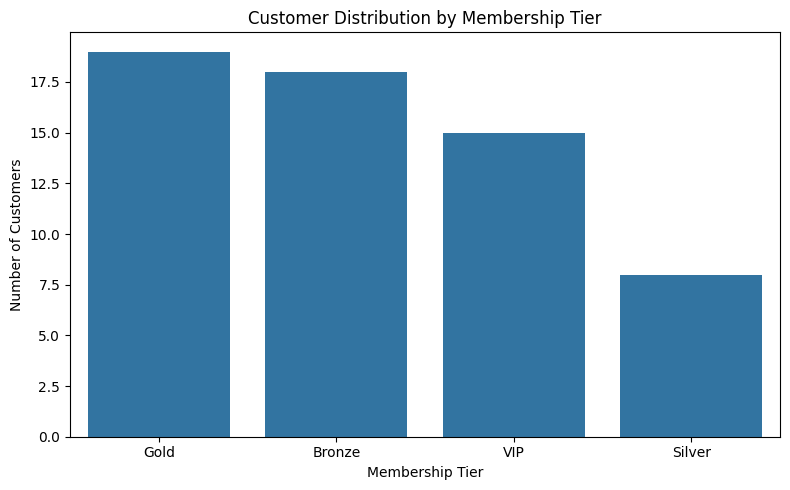

In [92]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="membership_tier",
    order=df["membership_tier"].value_counts().index
)

plt.title("Customer Distribution by Membership Tier")
plt.xlabel("Membership Tier")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

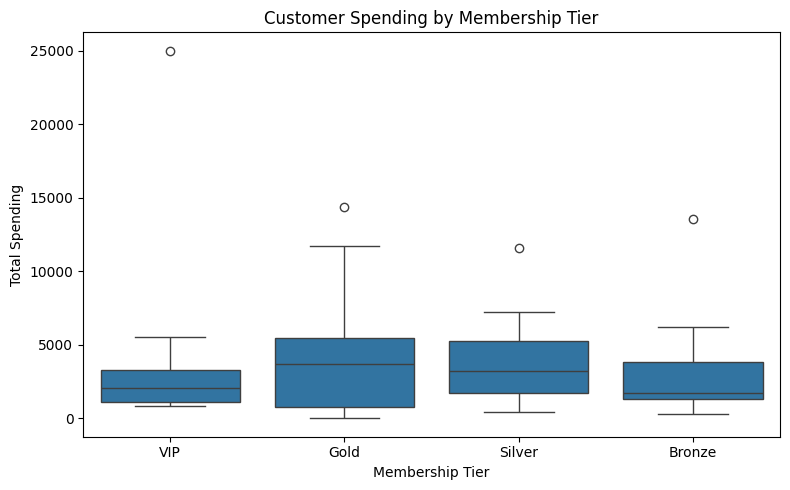

In [93]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="membership_tier",
    y="total_spending"
)

plt.title("Customer Spending by Membership Tier")
plt.xlabel("Membership Tier")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.show()

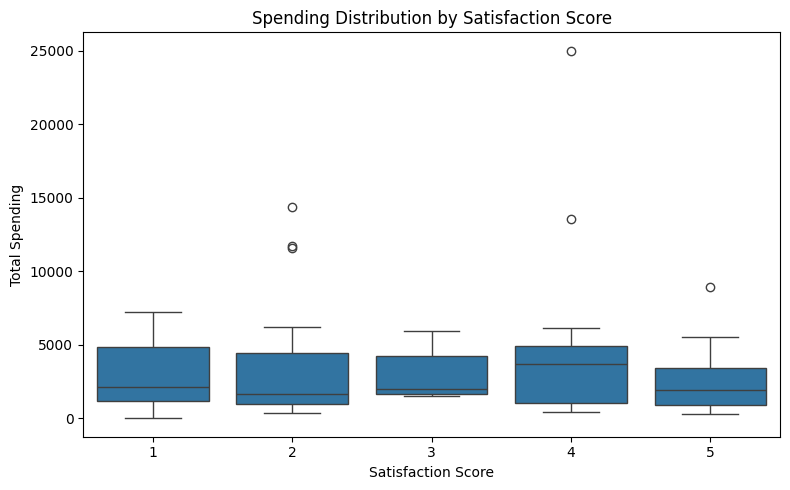

In [94]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="satisfaction_score",
    y="total_spending"
)

plt.title("Spending Distribution by Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.show()

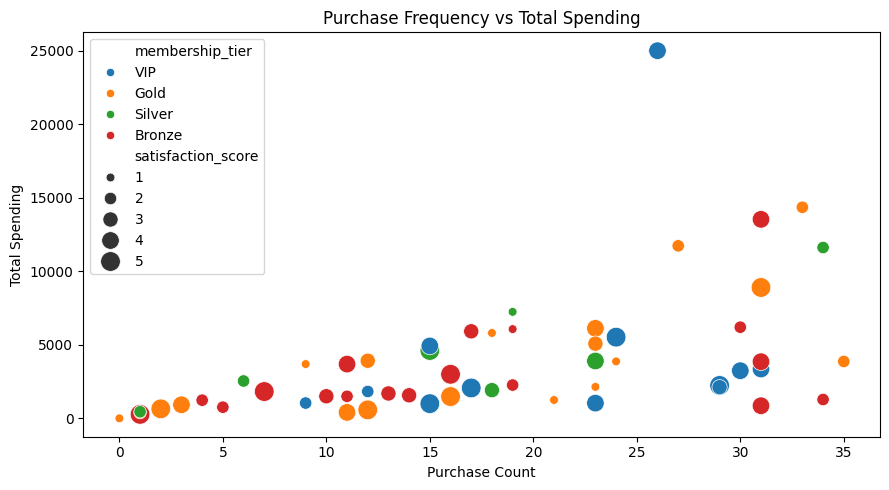

In [95]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="purchase_count",
    y="total_spending",
    hue="membership_tier",
    size="satisfaction_score",
    sizes=(40, 200)
)

plt.title("Purchase Frequency vs Total Spending")
plt.xlabel("Purchase Count")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.show()

# 17. CORRELATION ANALYSIS

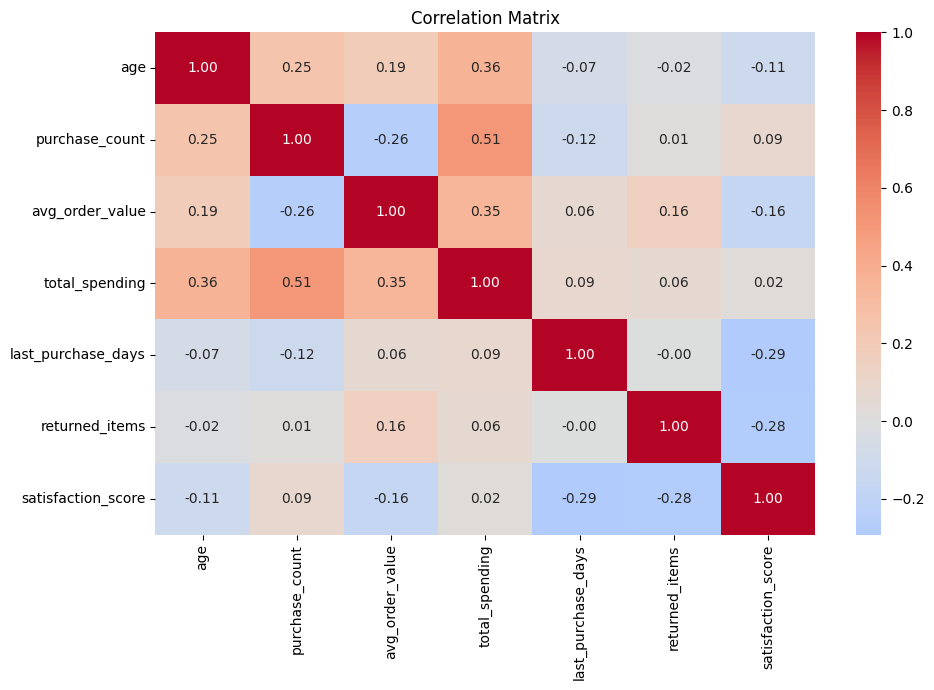

In [96]:
correlation_columns = [
    "age",
    "purchase_count",
    "avg_order_value",
    "total_spending",
    "last_purchase_days",
    "returned_items",
    "satisfaction_score"
]

corr = df[correlation_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

# 18. FINAL DATA QUALITY REPORT

In [97]:
quality_report = pd.DataFrame({
    "Metric": [
        "Number of Rows",
        "Number of Columns",
        "Missing Values",
        "Duplicate Rows",
        "Duplicate Customer IDs",
        "Invalid Age Records",
        "Return Consistency Issues",
        "Spending Consistency Issues"
    ],

    "Value": [
        len(df),
        df.shape[1],
        df.isna().sum().sum(),
        df.duplicated().sum(),
        df["customer_id"].duplicated().sum(),
        ((df["age"] < 18) | (df["age"] > 100)).sum(),
        df["returns_data_issue"].sum(),
        (df["spending_difference"].abs() > 1).sum()
    ]
})

display(quality_report)

,Metric,Value
0,Number of Rows,60
1,Number of Columns,23
2,Missing Values,1
3,Duplicate Rows,0
4,Duplicate Customer IDs,0
5,Invalid Age Records,0
6,Return Consistency Issues,6
7,Spending Consistency Issues,1


# 19. EXPORT CLEAN DATASET

In [98]:
clean_df = df.copy()

# Remove helper columns before exporting
clean_df = clean_df.drop(
    columns=[
        "calculated_spending",
        "spending_difference"
    ],
    errors="ignore"
)

output_file = "cleaned_customer_dataset.xlsx"

clean_df.to_excel(
    output_file,
    index=False
)

print(f"Clean dataset saved as: {output_file}")

Clean dataset saved as: cleaned_customer_dataset.xlsx


In [99]:
from google.colab import files

files.download("cleaned_customer_dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>